**skin cancer
**

In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os, json

kaggle_creds = {
    "username": "YOUR_KAGGLE_USERNAME",
    "key": "YOUR_API_KEY"
}

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/SkinCancerData --unzip

print(os.listdir('/content/SkinCancerData'))

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:32<00:00, 170MB/s]

['ham10000_images_part_1', 'HAM10000_images_part_2', 'hmnist_8_8_L.csv', 'hmnist_28_28_RGB.csv', 'HAM10000_metadata.csv', 'hmnist_8_8_RGB.csv', 'ham10000_images_part_2', 'hmnist_28_28_L.csv', 'HAM10000_images_part_1']


In [5]:
import os
for item in os.listdir('/content/SkinCancerData'):
    print(item)

ham10000_images_part_1
HAM10000_images_part_2
hmnist_8_8_L.csv
hmnist_28_28_RGB.csv
HAM10000_metadata.csv
hmnist_8_8_RGB.csv
ham10000_images_part_2
hmnist_28_28_L.csv
HAM10000_images_part_1


In [6]:
import pandas as pd

metadata = pd.read_csv('/content/SkinCancerData/HAM10000_metadata.csv')
print(metadata.head())
print(metadata['dx'].value_counts())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


In [7]:
import glob

all_image_paths = glob.glob('/content/SkinCancerData/**/*.jpg', recursive=True)
image_path_dict = {os.path.splitext(os.path.basename(p))[0]: p for p in all_image_paths}

print(f"Found {len(image_path_dict)} images")
metadata['path'] = metadata['image_id'].map(image_path_dict)
print(metadata['path'].isna().sum(), "images not found")  # should be 0

Found 10015 images
0 images not found


In [8]:
from torch.utils.data import Dataset
from PIL import Image

class_names = sorted(metadata['dx'].unique())
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
print("Classes:", class_names)

class HAM10000Dataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        img = self.transform(img)
        label = class_to_idx[row['dx']]
        return img, label

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


In [9]:
from sklearn.model_selection import train_test_split
from torchvision import transforms

train_df, temp_df = train_test_split(metadata, test_size=0.2, stratify=metadata['dx'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['dx'], random_state=42)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_set = HAM10000Dataset(train_df, train_transform)
val_set = HAM10000Dataset(val_df, eval_transform)
test_set = HAM10000Dataset(test_df, eval_transform)

Train: 8012, Val: 1001, Test: 1002


In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [11]:
import torchvision.models as models
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

model = models.resnet50(weights='IMAGENET1K_V2')
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to('cuda')

# compute class weights so the loss function penalizes mistakes on rare classes more
train_labels = train_df['dx'].map(class_to_idx).values
class_weights = compute_class_weight('balanced', classes=np.arange(len(class_names)), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to('cuda')
print("Class weights:", class_weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 59.5MB/s]


Class weights: tensor([ 4.3686,  2.7848,  1.3021, 12.4410,  1.2860,  0.2134, 10.0401],
       device='cuda:0')


In [12]:
import torchvision.models as models
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

model = models.resnet50(weights='IMAGENET1K_V2')
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to('cuda')

# compute class weights so the loss function penalizes mistakes on rare classes more
train_labels = train_df['dx'].map(class_to_idx).values
class_weights = compute_class_weight('balanced', classes=np.arange(len(class_names)), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to('cuda')
print("Class weights:", class_weights)

Class weights: tensor([ 4.3686,  2.7848,  1.3021, 12.4410,  1.2860,  0.2134, 10.0401],
       device='cuda:0')


In [13]:
import torchvision.models as models
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

model = models.resnet50(weights='IMAGENET1K_V2')
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to('cuda')

# compute class weights so the loss function penalizes mistakes on rare classes more
train_labels = train_df['dx'].map(class_to_idx).values
class_weights = compute_class_weight('balanced', classes=np.arange(len(class_names)), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to('cuda')
print("Class weights:", class_weights)

Class weights: tensor([ 4.3686,  2.7848,  1.3021, 12.4410,  1.2860,  0.2134, 10.0401],
       device='cuda:0')


In [14]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {running_loss/len(train_loader):.4f} — Val Acc: {val_acc:.4f}")

Epoch 1/10 — Loss: 1.5346 — Val Acc: 0.6044
Epoch 2/10 — Loss: 1.2139 — Val Acc: 0.6364
Epoch 3/10 — Loss: 1.1306 — Val Acc: 0.6294
Epoch 4/10 — Loss: 1.0472 — Val Acc: 0.6663
Epoch 5/10 — Loss: 0.9893 — Val Acc: 0.6653
Epoch 6/10 — Loss: 0.9735 — Val Acc: 0.6873
Epoch 7/10 — Loss: 0.9312 — Val Acc: 0.6623
Epoch 8/10 — Loss: 0.9038 — Val Acc: 0.6853
Epoch 9/10 — Loss: 0.8746 — Val Acc: 0.7053
Epoch 10/10 — Loss: 0.8518 — Val Acc: 0.6943


In [15]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.0001)
num_epochs_finetune = 5

for epoch in range(num_epochs_finetune):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    print(f"Fine-tune Epoch {epoch+1}/{num_epochs_finetune} — Loss: {running_loss/len(train_loader):.4f} — Val Acc: {val_acc:.4f}")

Fine-tune Epoch 1/5 — Loss: 0.7554 — Val Acc: 0.7512
Fine-tune Epoch 2/5 — Loss: 0.5175 — Val Acc: 0.7852
Fine-tune Epoch 3/5 — Loss: 0.3962 — Val Acc: 0.8152
Fine-tune Epoch 4/5 — Loss: 0.2965 — Val Acc: 0.8262
Fine-tune Epoch 5/5 — Loss: 0.2714 — Val Acc: 0.8442


              precision    recall  f1-score   support

       akiec       0.71      0.78      0.75        32
         bcc       0.70      0.90      0.79        52
         bkl       0.74      0.81      0.77       110
          df       0.58      1.00      0.73        11
         mel       0.59      0.66      0.62       112
          nv       0.96      0.88      0.92       671
        vasc       0.81      0.93      0.87        14

    accuracy                           0.85      1002
   macro avg       0.73      0.85      0.78      1002
weighted avg       0.87      0.85      0.86      1002



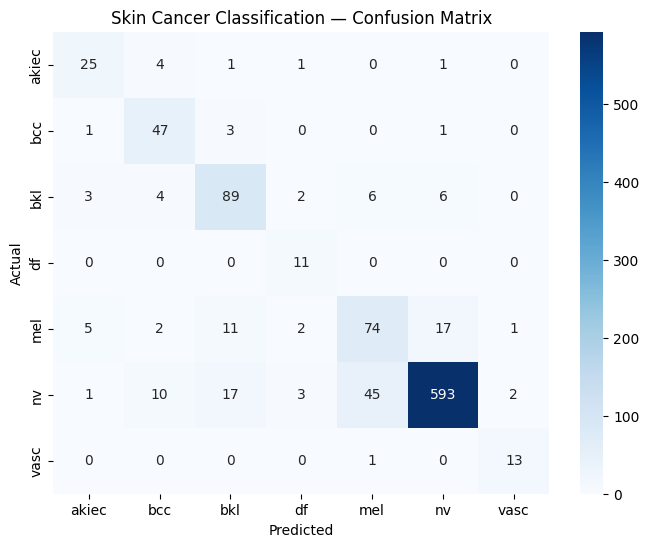

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to('cuda')
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Skin Cancer Classification — Confusion Matrix')
plt.savefig('/content/drive/MyDrive/skin_cancer_confusion_matrix.png')
plt.show()

In [17]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names
}, '/content/drive/MyDrive/skin_cancer_model.pt')

print("Saved to /content/drive/MyDrive/skin_cancer_model.pt")

Saved to /content/drive/MyDrive/skin_cancer_model.pt
